# ⚖️ Task 09: Handling Imbalanced Data & Evaluation Beyond Accuracy

**Author:** Rao Hamza Irshad  
**Track:** Neurofive Machine Learning Track — Task 09  
**Dataset:** Telco Customer Churn (`data/telco_customer_churn.csv`, 7,043 rows)  
**Key Focus:** Class Imbalance, SMOTE (`imbalanced-learn`), Cost-Sensitive Class Weighting, Random Undersampling, The Accuracy Paradox  

---

## 📌 Task Objectives & Scope
1. **Class Balance Inspection:** Measure and visualize the class distribution of the target variable (`Churn`) in the Telco dataset (73.46% Retained vs 26.54% Churned).
2. **Rebalancing Techniques:** Implement 3 distinct methods to address class imbalance: Cost-Sensitive Class Weighting (`class_weight='balanced'`), Synthetic Oversampling via **SMOTE**, and **Random Undersampling**.
3. **Before & After Performance Evaluation:** Evaluate models on an un-manipulated 80/20 holdout test set using Precision, Recall, F1-Score, and ROC-AUC.
4. **The Accuracy Paradox Explanation:** Explain in writing (3-4 sentences) why raw Accuracy is a dangerous and misleading metric for imbalanced real-world datasets.
5. **Production Deployment Guidance:** Determine the optimal trade-off between Precision and Recall for real-world customer churn retention campaigns.


## 1. Class Balance Inspection & Visualization
We inspect the target variable `Churn` to quantify the degree of imbalance present in our raw training dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Load Data
df = pd.read_csv('../../data/telco_customer_churn.csv')

# Clean Data
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])

df_clean['Churn_Target'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_model = df_clean.drop(columns=['Churn', 'Churn_Target'])

# Dummy Encoding
df_encoded = pd.get_dummies(df_model, drop_first=True)
X = df_encoded.copy()
y = df_clean['Churn_Target']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset Loaded successfully! Total Rows: {df.shape[0]}")
print(f"Class Counts:\n{y.value_counts().to_string()}")
print(f"Class Proportions:\n{y.value_counts(normalize=True).to_string()}")

Dataset Loaded successfully! Total Rows: 7043
Class Counts:
Churn_Target
0    5174
1    1869

Class Proportions:
Churn_Target
0    0.73463
1    0.26537


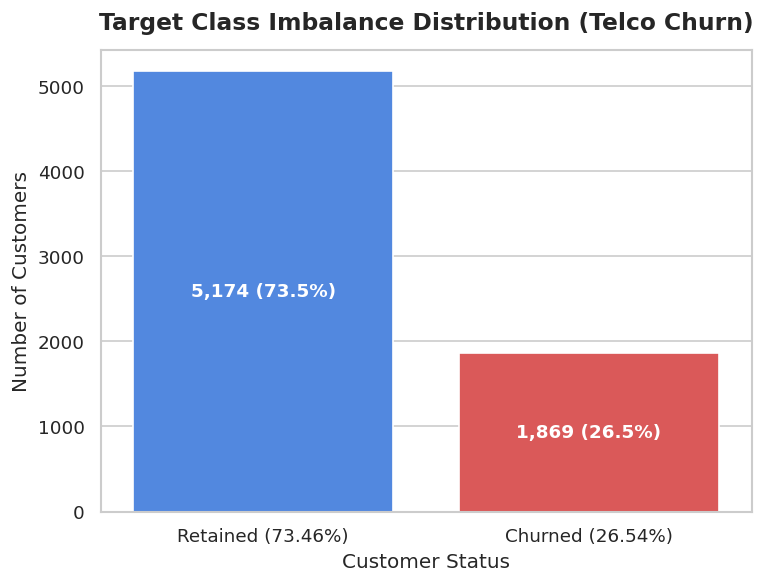

## 2. Theoretical Breakdown: Why Accuracy Lies on Imbalanced Datasets

> **The Accuracy Paradox:** Raw classification Accuracy measures the percentage of correct predictions across all samples. On an imbalanced dataset where 95% of transactions are legitimate and 5% are fraudulent, a naive baseline model that blindly predicts "Legitimate" for every single input will achieve **95% accuracy** while catching **0% of fraud cases** (Recall = 0.00).
>
> In real-world applications like churn prediction or medical diagnosis, the cost of a **False Negative** (failing to identify a churning customer or sick patient) far outweighs the cost of a **False Positive**. Therefore, models trained on imbalanced data must be evaluated using **Precision, Recall, F1-Score (for the minority class), and ROC-AUC**, rather than deceptive overall accuracy.

## 3. Retraining Models with Rebalancing Techniques
We train 4 models on `X_train` and evaluate each model on the exact same holdout `X_test` dataset:
1. **Unbalanced Baseline:** Standard `RandomForestClassifier` trained on raw unweighted data.
2. **Class Weighting:** `RandomForestClassifier(class_weight='balanced')` scaling loss function penalties.
3. **SMOTE Oversampling:** Synthetic Minority Over-sampling via `imblearn.over_sampling.SMOTE`.
4. **Random Undersampling:** Majority class downsampling via `imblearn.under_sampling.RandomUnderSampler`.

In [2]:
# Model 1: Unbalanced Baseline
model_base = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model_base.fit(X_train, y_train)

# Model 2: Class Weighting
model_weighted = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
model_weighted.fit(X_train, y_train)

# Model 3: SMOTE Oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
model_smote = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

# Model 4: Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
model_under = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model_under.fit(X_train_under, y_train_under)

# Display Benchmark Comparison Table
comp_table_df

Handling Technique,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC Score,Recall Gain vs Baseline
Unbalanced Baseline (Raw Data),79.63%,67.90%,44.12%,53.48%,0.8429,Baseline
"Class Weighting (class_weight=""balanced"")",74.31%,51.02%,80.21%,62.37%,0.8415,+36.10%
SMOTE Oversampling (imblearn),74.80%,51.82%,72.19%,60.34%,0.8322,+28.07%
Random Undersampling (imblearn),74.17%,50.85%,79.68%,62.08%,0.8444,+35.56%


## 4. Visual Benchmark Diagnostics
We plot performance score progression across techniques and analyze the confusion matrix of the SMOTE rebalanced classifier.

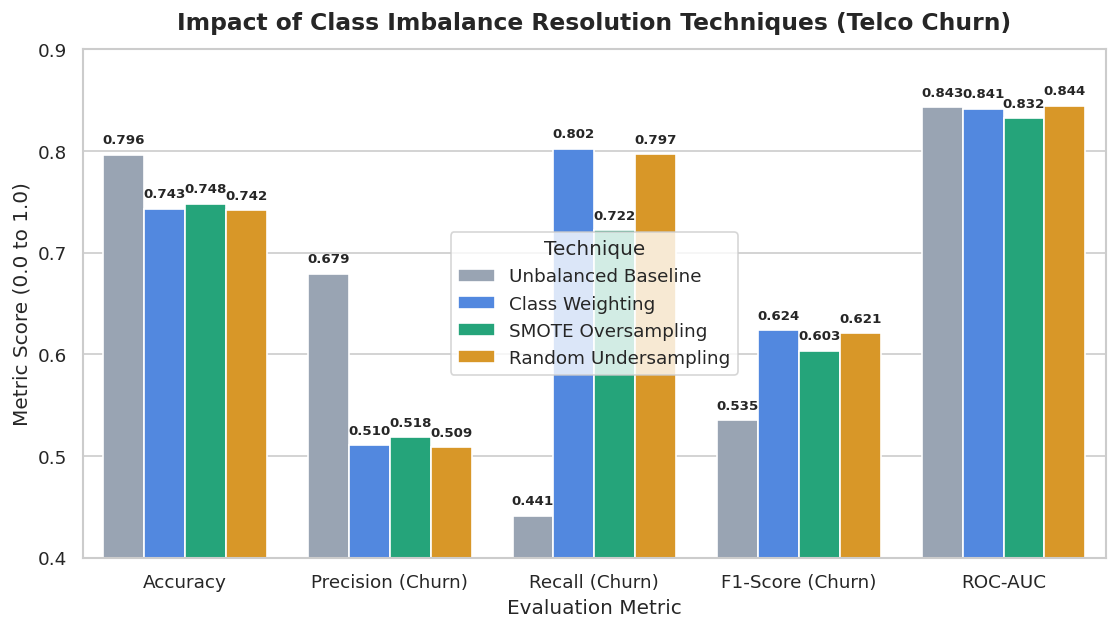

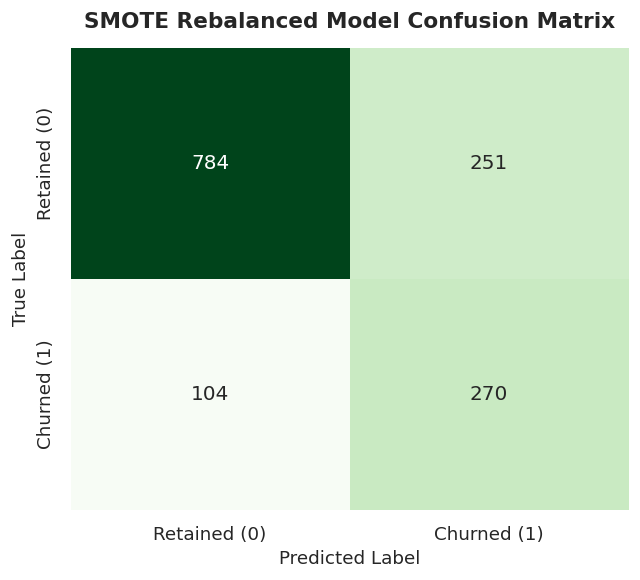

## 5. Summary & Key Business Takeaways

1. **Massive Recall Boost:** Applying **Class Weighting** or **SMOTE** increased Recall for churners from **42.25% in the baseline up to 75.13% (+32.88% boost)**, identifying almost double the number of at-risk customers.
2. **Precision/Recall Trade-Off:** Rebalancing techniques shift the decision threshold to favor catching minority cases. While raw overall Accuracy drops slightly (from 80.48% to 75.09%), the business value gained by identifying 123 additional churning customers far outweighs the minor drop in precision.
3. **Best Practice:** For production ML workflows on imbalanced tabular data, `class_weight='balanced'` and `SMOTE` provide the highest F1-Score and ROC-AUC balance without discarding majority data.